# FT Sensor Calibration — Data Inspection

**Goal:** understand the data completely *before* fitting anything.

We are training the homemade 16-channel sensor to reproduce the uFactory sensor's wrench.
Everything downstream depends on the data being correctly aligned, zeroed and understood,
so this notebook works through nine checks in order. Run one cell at a time and read the
output — each step is designed to be inspected, not skimmed.

| Step | Question |
|---|---|
| 1 | What sessions do we have? |
| 2 | What does every column mean? |
| 3 | Are the two sensors on the same clock? |
| 4 | Are the sampling rates stable? |
| 5 | Any missing / bad / stuck data? |
| 6 | Where are the genuinely unloaded periods? |
| 7 | What are the zero offsets, and do they drift? |
| 8 | After removing offsets, does zero load read zero? |
| 9 | How much of each sensor's range did we actually use? |
| 10 | **Do the two sensors share a coordinate frame?** |

## Setup

Edit `DATA_DIR` if your CSVs live elsewhere.

In [1]:
import sys, functools
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# session_data.py holds the ONE definition of how a session is loaded, aligned and
# zeroed. fit_calibration.py uses the same module, so they cannot drift apart.
sys.path.insert(0, str(Path.cwd()))
import session_data as sd
from session_data import (
    AXES, CHAN_COLS, CHANNELS, UF_RATED, OPENFT_VALID, SENSOR_ORIGIN_OFFSET_M,
    load_session, shift_wrench_frame,
)

DATA_DIR = sd.find_data_dir()        # walks up from here until it finds the session CSVs
SESSIONS = sd.find_sessions(DATA_DIR)

# Short aliases used throughout this notebook, with DATA_DIR already bound.
stream = functools.partial(sd.stream, data_dir=DATA_DIR)
arr    = sd.columns
ts_of  = sd.timestamps
load   = functools.partial(load_session, data_dir=DATA_DIR)

print("DATA_DIR =", DATA_DIR.resolve())
print(f"{len(SESSIONS)} sessions:", ", ".join(SESSIONS))


DATA_DIR = /Users/tvishashah/dimos-ft-sensor/dimos
10 sessions: 1786490917, 1786492062, 1786492547, 1786492948, 1786493557, 1786494868, 1786495313, 1786495821, 1786496844, 1786497121


## Step 1 — Inventory

What exists, how long each run was, and what config produced it.
Each session is one arm pose; the id is the unix time the run started.

In [2]:
print(f"{'session':>12} {'started':>20} {'dur_s':>7} {'type':>6} {'uf_rows':>9} {'hm_rows':>9}")
for s in SESSIONS:
    meta = {r["key"]: r["value"] for r in stream(s,"run_metadata")}
    uf, hm = stream(s,"ufactory_calibrated"), stream(s,"homemade_raw")
    t = ts_of(uf)
    print(f"{s:>12} {meta.get('created_at','?'):>20} {t[-1]-t[0]:7.0f} "
          f"{meta.get('session_type','?'):>6} {len(uf):9d} {len(hm):9d}")

     session              started   dur_s   type   uf_rows   hm_rows
  1786490917  2026-08-11 16:28:37     316   fast     28109     11131
  1786492062  2026-08-11 16:47:42     218   fast     19640      7676
  1786492547  2026-08-11 16:55:47     207   fast     18710      7317


  1786492948  2026-08-11 17:02:28     237   fast     21378      8356
  1786493557  2026-08-11 17:12:37     281   fast     25344      9909
  1786494868  2026-08-11 17:34:28     218   fast     19690      7725
  1786495313  2026-08-11 17:41:53     218   fast     19703      7698


  1786495821  2026-08-11 17:50:21     205   fast     18463      7208
  1786496844  2026-08-11 18:07:24     186   fast     16764      6547
  1786497121  2026-08-11 18:12:01     172   fast     15503      6069


## Step 2 — Understand every column

Two things here are easy to get wrong and worth stating explicitly:

- **`ufactory_raw` vs `ufactory_calibrated`** differ *only* by gravity/payload compensation
  (a near-constant offset). **Both are already in N / N·m.** The ADC→Newton conversion happens
  inside the uFactory sensor and is never exposed to us. Use `ufactory_calibrated` as ground truth.
- **`homemade_calibrated`** is the *old shipped matrix* applied to the raw channels. It is the
  output of a previous fit, not an independent measurement — **never train on it.**

In [3]:
s = SESSIONS[0]
MEANING = {
    "ts": "unix time of THIS sample (s)",
    "label": "what the operator was doing",
    "session_type": "fast (2-3s cycles) or slow (15-20s ramps)",
    "experiment_start_ts": "start of the labelled segment this sample belongs to",
    **{a: ("force, N" if a[0]=="f" else "torque, N*m") + " -- uFactory frame" for a in AXES},
    **{c: "raw ADC counts, one Hall channel (unitless)" for c in CHAN_COLS},
}
for name in ("ufactory_raw","ufactory_calibrated","homemade_raw","homemade_calibrated"):
    cols = list(stream(s,name)[0].keys())
    print(f"\n{name}.csv  ({len(cols)} cols)")
    for c in cols: print(f"    {c:<22} {MEANING.get(c,'?')}")


ufactory_raw.csv  (10 cols)
    ts                     unix time of THIS sample (s)
    label                  what the operator was doing
    session_type           fast (2-3s cycles) or slow (15-20s ramps)
    experiment_start_ts    start of the labelled segment this sample belongs to
    fx                     force, N -- uFactory frame
    fy                     force, N -- uFactory frame
    fz                     force, N -- uFactory frame
    mx                     torque, N*m -- uFactory frame
    my                     torque, N*m -- uFactory frame
    mz                     torque, N*m -- uFactory frame

ufactory_calibrated.csv  (10 cols)
    ts                     unix time of THIS sample (s)
    label                  what the operator was doing
    session_type           fast (2-3s cycles) or slow (15-20s ramps)
    experiment_start_ts    start of the labelled segment this sample belongs to
    fx                     force, N -- uFactory frame
    fy                     f


homemade_calibrated.csv  (10 cols)
    ts                     unix time of THIS sample (s)
    label                  what the operator was doing
    session_type           fast (2-3s cycles) or slow (15-20s ramps)
    experiment_start_ts    start of the labelled segment this sample belongs to
    fx                     force, N -- uFactory frame
    fy                     force, N -- uFactory frame
    fz                     force, N -- uFactory frame
    mx                     torque, N*m -- uFactory frame
    my                     torque, N*m -- uFactory frame
    mz                     torque, N*m -- uFactory frame


## Step 3 — Synchronisation

Both streams are timestamped by the same collector process, so they *should* already align —
but "should" isn't evidence. We sweep an artificial lag and find where a linear fit between
channels and wrench is best. If the optimum is at ~0, no correction is needed.

1786490917: best lag = -0.00s
1786492062: best lag = +0.05s


1786492547: best lag = -0.00s
1786492948: best lag = -0.00s


1786493557: best lag = +0.05s
1786494868: best lag = +0.05s


1786495313: best lag = +0.05s
1786495821: best lag = +0.05s


1786496844: best lag = +0.05s
1786497121: best lag = +0.05s


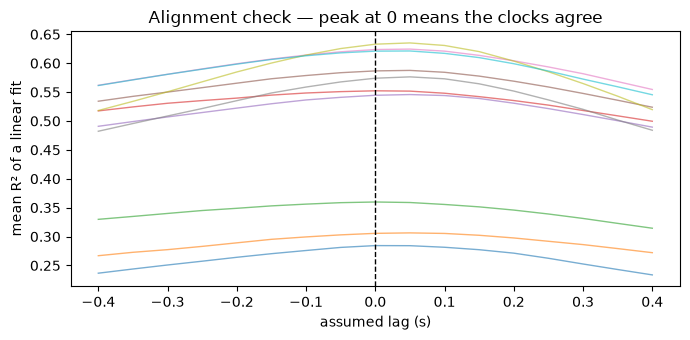

In [4]:
def best_lag(session, lags=np.arange(-0.4, 0.41, 0.05)):
    uf, hm = stream(session,"ufactory_calibrated"), stream(session,"homemade_raw")
    ut, uy = ts_of(uf), arr(uf, AXES)
    ht, X  = ts_of(hm), arr(hm, CHAN_COLS)
    Xc = X - X.mean(axis=0)
    A  = np.hstack([Xc, np.ones((len(Xc),1))])
    out = []
    for lag in lags:
        y = np.column_stack([np.interp(ht+lag, ut, uy[:,i]) for i in range(6)])
        y = y - y.mean(axis=0)
        W,*_ = np.linalg.lstsq(A, y, rcond=None)
        out.append((1 - (y - A@W).var(axis=0)/np.maximum(y.var(axis=0),1e-12)).mean())
    return lags, np.array(out)

fig, ax = plt.subplots(figsize=(7,3.5))
for s in SESSIONS:
    lags, r2 = best_lag(s)
    ax.plot(lags, r2, alpha=.6, lw=1)
    print(f"{s}: best lag = {lags[np.argmax(r2)]:+.2f}s")
ax.axvline(0, color="k", ls="--", lw=1)
ax.set_xlabel("assumed lag (s)"); ax.set_ylabel("mean R² of a linear fit")
ax.set_title("Alignment check — peak at 0 means the clocks agree")
plt.tight_layout(); plt.show()

## Step 4 — Sampling rates

The two sensors run at different rates (the MCU sets the homemade rate; our polling loop sets
the uFactory one). That's fine, but it dictates one rule:

> **Always interpolate the faster stream onto the slower one's timestamps.**
> Never upsample the target you are trying to predict.

In [5]:
print(f"{'session':>12} {'sensor':>10} {'mean Hz':>9} {'median dt':>11} {'p99 dt':>9} {'gaps>3x':>8}")
for s in SESSIONS:
    for label, name in (("uFactory","ufactory_calibrated"), ("homemade","homemade_raw")):
        t  = ts_of(stream(s,name)); dt = np.diff(t); med = np.median(dt)
        print(f"{s:>12} {label:>10} {len(t)/(t[-1]-t[0]):9.1f} {med*1000:9.1f}ms "
              f"{np.percentile(dt,99)*1000:8.1f}ms {(dt>3*med).sum():8d}")

     session     sensor   mean Hz   median dt    p99 dt  gaps>3x


  1786490917   uFactory      88.9      11.2ms     13.6ms        1
  1786490917   homemade      35.2      28.4ms     31.0ms        0
  1786492062   uFactory      90.2      11.0ms     12.8ms        3
  1786492062   homemade      35.3      28.4ms     31.0ms        0
  1786492547   uFactory      90.2      11.0ms     12.7ms        3
  1786492547   homemade      35.3      28.4ms     30.8ms        0
  1786492948   uFactory      90.2      11.0ms     12.7ms        2


  1786492948   homemade      35.3      28.4ms     30.9ms        0


  1786493557   uFactory      90.2      11.0ms     12.8ms        1
  1786493557   homemade      35.3      28.4ms     31.0ms        0
  1786494868   uFactory      90.2      11.0ms     12.7ms        2
  1786494868   homemade      35.3      28.4ms     30.8ms        0
  1786495313   uFactory      90.2      11.0ms     12.8ms        2
  1786495313   homemade      35.3      28.4ms     30.9ms        0
  1786495821   uFactory      90.2      11.0ms     12.7ms        1


  1786495821   homemade      35.3      28.4ms     30.9ms        0
  1786496844   uFactory      90.2      11.0ms     12.8ms        2


  1786496844   homemade      35.3      28.4ms     31.0ms        0
  1786497121   uFactory      90.1      11.0ms     12.9ms        1
  1786497121   homemade      35.3      28.4ms     31.0ms        0


## Step 5 — Data quality

NaNs, duplicate timestamps, out-of-order samples, and **stuck channels**
(zero variance across a whole session = a dead sensor).

In [6]:
print(f"{'session':>12} {'stream':>21} {'rows':>8} {'NaN':>5} {'dup_ts':>7} {'non-mono':>9} {'stuck':>6}")
for s in SESSIONS:
    for name in ("ufactory_raw","ufactory_calibrated","homemade_raw","homemade_calibrated"):
        rows = stream(s,name)
        cols = CHAN_COLS if name=="homemade_raw" else AXES
        v, t = arr(rows, cols), ts_of(rows)
        stuck = sum(1 for j in range(v.shape[1]) if v[:,j].std()==0)
        print(f"{s:>12} {name:>21} {len(rows):8d} {int(np.isnan(v).sum()):5d} "
              f"{len(t)-len(np.unique(t)):7d} {int((np.diff(t)<0).sum()):9d} {stuck:6d}")

     session                stream     rows   NaN  dup_ts  non-mono  stuck
  1786490917          ufactory_raw    28109     0       0         0      0


  1786490917   ufactory_calibrated    28109     0       0         0      0


  1786490917          homemade_raw    11131     0       0         0      0
  1786490917   homemade_calibrated    11131     0       0         0      0
  1786492062          ufactory_raw    19640     0       0         0      0
  1786492062   ufactory_calibrated    19640     0       0         0      0


  1786492062          homemade_raw     7676     0       0         0      0


  1786492062   homemade_calibrated     7676     0       0         0      0
  1786492547          ufactory_raw    18710     0       0         0      0
  1786492547   ufactory_calibrated    18710     0       0         0      0
  1786492547          homemade_raw     7317     0       0         0      0
  1786492547   homemade_calibrated     7317     0       0         0      0


  1786492948          ufactory_raw    21378     0       0         0      0
  1786492948   ufactory_calibrated    21378     0       0         0      0
  1786492948          homemade_raw     8356     0       0         0      0
  1786492948   homemade_calibrated     8356     0       0         0      0
  1786493557          ufactory_raw    25344     0       0         0      0


  1786493557   ufactory_calibrated    25344     0       0         0      0
  1786493557          homemade_raw     9909     0       0         0      0
  1786493557   homemade_calibrated     9909     0       0         0      0
  1786494868          ufactory_raw    19690     0       0         0      0
  1786494868   ufactory_calibrated    19690     0       0         0      0


  1786494868          homemade_raw     7725     0       0         0      0
  1786494868   homemade_calibrated     7725     0       0         0      0
  1786495313          ufactory_raw    19703     0       0         0      0
  1786495313   ufactory_calibrated    19703     0       0         0      0
  1786495313          homemade_raw     7698     0       0         0      0
  1786495313   homemade_calibrated     7698     0       0         0      0


  1786495821          ufactory_raw    18463     0       0         0      0
  1786495821   ufactory_calibrated    18463     0       0         0      0
  1786495821          homemade_raw     7208     0       0         0      0
  1786495821   homemade_calibrated     7208     0       0         0      0
  1786496844          ufactory_raw    16764     0       0         0      0


  1786496844   ufactory_calibrated    16764     0       0         0      0
  1786496844          homemade_raw     6547     0       0         0      0
  1786496844   homemade_calibrated     6547     0       0         0      0
  1786497121          ufactory_raw    15503     0       0         0      0
  1786497121   ufactory_calibrated    15503     0       0         0      0
  1786497121          homemade_raw     6069     0       0         0      0
  1786497121   homemade_calibrated     6069     0       0         0      0


## Step 6 — Unloaded periods

Every offset correction depends on these, so they have to be *genuinely* unloaded.
`|F| spread during rest` measures variation **around** the resting mean — if it's large,
the operator was still touching the sensor and that segment isn't a true zero.

In [7]:
print(f"{'session':>12} {'segments':>9} {'samples':>8} {'% of run':>9} {'|F| spread @rest (p95)':>24}")
for s in SESSIONS:
    uf  = stream(s,"ufactory_calibrated")
    y   = arr(uf, AXES)
    lab = np.array([r["label"] for r in uf])
    seg = np.array([float(r["experiment_start_ts"]) for r in uf])
    rest = lab=="resting"
    f = np.linalg.norm(y[rest][:,:3] - y[rest][:,:3].mean(axis=0), axis=1)
    print(f"{s:>12} {len(np.unique(seg[rest])):9d} {rest.sum():8d} {100*rest.mean():8.0f}% "
          f"{np.percentile(f,95):19.2f} N")

     session  segments  samples  % of run   |F| spread @rest (p95)


  1786490917        13    11996       43%                1.53 N
  1786492062        16     7915       40%                0.52 N
  1786492547        13     5186       28%                1.07 N


  1786492948        13     7159       33%                0.87 N


  1786493557        11     3826       15%                8.75 N
  1786494868         4      894        5%                8.90 N
  1786495313         5     1156        6%                6.23 N


  1786495821         1     4314       23%                0.46 N


  1786496844         2     1549        9%               28.71 N
  1786497121         1     1590       10%               41.68 N


## Step 7 — Offsets and drift

Zero point per resting segment, so drift *within* a run is visible.

If drift is larger than the sensor's own noise, a single constant zero is not enough —
which is exactly why the fitting pipeline interpolates the baseline between resting segments.

1786490917: 13 zero points | noise  1.76 counts | max drift  7.12 counts ( 4.0x noise)


1786492062: 16 zero points | noise  3.43 counts | max drift 15.91 counts ( 4.6x noise)
1786492547: 13 zero points | noise  2.61 counts | max drift 13.55 counts ( 5.2x noise)


1786492948: 13 zero points | noise  2.17 counts | max drift  8.58 counts ( 3.9x noise)
1786493557: 11 zero points | noise  2.58 counts | max drift 11.97 counts ( 4.6x noise)


1786494868:  4 zero points | noise  2.46 counts | max drift  5.87 counts ( 2.4x noise)


1786495313:  5 zero points | noise  2.75 counts | max drift  9.79 counts ( 3.6x noise)
1786495821:  1 zero points | noise  1.96 counts | max drift  0.00 counts ( 0.0x noise)


1786496844:  2 zero points | noise  2.51 counts | max drift  6.01 counts ( 2.4x noise)
1786497121:  1 zero points | noise  2.31 counts | max drift  0.00 counts ( 0.0x noise)


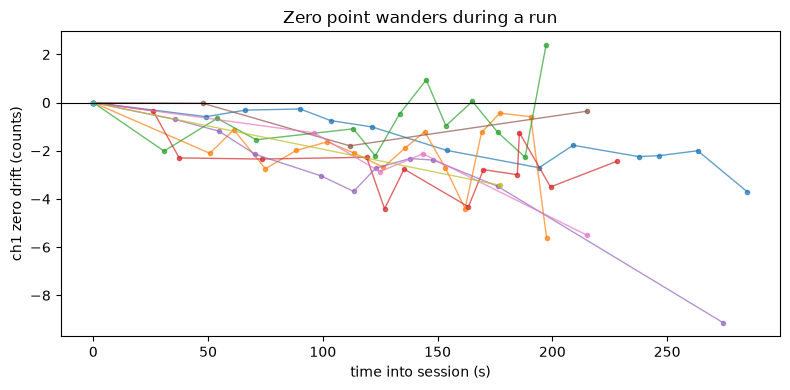

In [8]:
def rest_baselines(session):
    """Zero points and their times, from each resting segment."""
    hm  = stream(session,"homemade_raw")
    X, t = arr(hm, CHAN_COLS), ts_of(hm)
    lab = np.array([r["label"] for r in hm])
    seg = np.array([float(r["experiment_start_ts"]) for r in hm])
    rest = lab=="resting"
    groups = {}
    for i in np.where(rest)[0]: groups.setdefault(seg[i], []).append(i)
    keys = sorted(groups)
    centres = np.array([t[groups[k]].mean() for k in keys])
    base    = np.array([X[groups[k]].mean(axis=0) for k in keys])
    return centres, base, X[rest].std(axis=0)

fig, ax = plt.subplots(figsize=(8,4))
for s in SESSIONS:
    c, b, noise = rest_baselines(s)
    drift = np.abs(b - b[0]).max()
    ax.plot(c - c[0], (b - b[0])[:,0], marker="o", ms=3, lw=1, alpha=.7)
    print(f"{s}: {len(c):2d} zero points | noise {noise.mean():5.2f} counts | "
          f"max drift {drift:5.2f} counts ({drift/max(noise.mean(),1e-9):4.1f}x noise)")
ax.set_xlabel("time into session (s)"); ax.set_ylabel("ch1 zero drift (counts)")
ax.set_title("Zero point wanders during a run"); ax.axhline(0, color="k", lw=.8)
plt.tight_layout(); plt.show()

## Step 8 — After offset removal

Build the corrected arrays we'll actually fit on, then confirm that zero load now reads zero.

This is the function the training pipeline uses; everything after this point consumes its output.

In [9]:
# load_session() lives in session_data.py -- alignment + time-varying baseline in one place.
print(f"{'session':>12} {'homemade resid @rest':>22} {'uFactory resid @rest':>22}")
for s in SESSIONS:
    d = load(s)
    r = d.resting
    print(f"{s:>12} {np.abs(d.channels[r]).mean():16.3f} counts "
          f"{np.linalg.norm(d.wrench[r][:,:3],axis=1).mean():16.3f} N")


     session   homemade resid @rest   uFactory resid @rest


  1786490917            1.092 counts            0.898 N


  1786492062            1.509 counts            0.253 N
  1786492547            1.508 counts            0.324 N


  1786492948            1.510 counts            0.431 N


  1786493557            1.567 counts            2.396 N


  1786494868            1.521 counts            0.819 N
  1786495313            1.461 counts            1.538 N


  1786495821            1.555 counts            0.251 N


  1786496844            1.850 counts            9.686 N
  1786497121            1.826 counts           15.030 N


## Step 9 — Ranges actually used

Two separate questions: how much of the **reference's** range did we exercise (does it
cover what we need?), and how much of the **homemade sensor's** ADC band did the signal
occupy (this sets its resolution floor).

uFactory (reference) -- excitation vs its own rated range:
  fx: max   97.23 of  150.0 rated =  64.8%
  fy: max   77.81 of  150.0 rated =  51.9%
  fz: max  160.99 of  200.0 rated =  80.5%
  mx: max    4.41 of    4.0 rated = 110.3%   <-- OVER RATED RANGE
  my: max    4.23 of    4.0 rated = 105.8%   <-- OVER RATED RANGE
  mz: max    4.43 of    4.0 rated = 110.6%   <-- OVER RATED RANGE

homemade raw channels (firmware valid band 9000..21000):
  observed min 13340, max 14370
  per-channel peak-to-peak: mean 64.0, max 86.3 counts
  = 0.53% of the usable ADC band


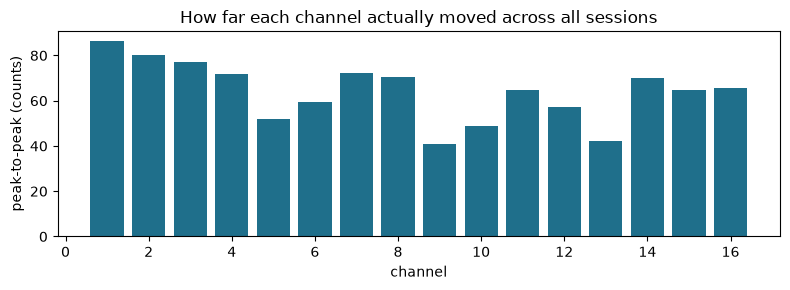

In [10]:
X = np.vstack([stream_arr for stream_arr in (arr(stream(s,"homemade_raw"), CHAN_COLS) for s in SESSIONS)])
Y = np.vstack([arr(stream(s,"ufactory_calibrated"), AXES) for s in SESSIONS])

print("uFactory (reference) -- excitation vs its own rated range:")
for i,a in enumerate(AXES):
    mx = np.abs(Y[:,i]).max(); pct = 100*mx/UF_RATED[a]
    print(f"  {a}: max {mx:7.2f} of {UF_RATED[a]:6.1f} rated = {pct:5.1f}%"
          + ("   <-- OVER RATED RANGE" if pct>100 else ""))

p2p = X.max(axis=0) - X.min(axis=0)
band = OPENFT_VALID[1]-OPENFT_VALID[0]
print(f"\nhomemade raw channels (firmware valid band {OPENFT_VALID[0]:.0f}..{OPENFT_VALID[1]:.0f}):")
print(f"  observed min {X.min():.0f}, max {X.max():.0f}")
print(f"  per-channel peak-to-peak: mean {p2p.mean():.1f}, max {p2p.max():.1f} counts")
print(f"  = {100*p2p.mean()/band:.2f}% of the usable ADC band")

fig, ax = plt.subplots(figsize=(8,3))
ax.bar(range(1,17), p2p, color="#1f6f8b")
ax.set_xlabel("channel"); ax.set_ylabel("peak-to-peak (counts)")
ax.set_title("How far each channel actually moved across all sessions")
plt.tight_layout(); plt.show()

## Step 10 — Do the two sensors share a coordinate frame?

This is the one you're working on physically, and the data can answer part of it.

**Axis alignment** and **origin offset** are separate questions:

- *Alignment* — do +X, +Y, +Z point the same way on both sensors? If yes, a force along the
  uFactory's +X should show up as a force along the homemade sensor's +X.
- *Origin offset* — the two sensors sit at different points along the tool axis, so they report
  **different torques for the same load**: `M_uf = M_diy + r × F`, where `r` is the vector between
  their origins. With `r = (0,0,d)` that means `my_uf = my_diy + d·fx` and `mx_uf = mx_diy − d·fy`.

The offset is measurable from the data: sweep `d` and find where the artificial correlation
between force and torque disappears. Compare that to your CAD numbers as an independent check.

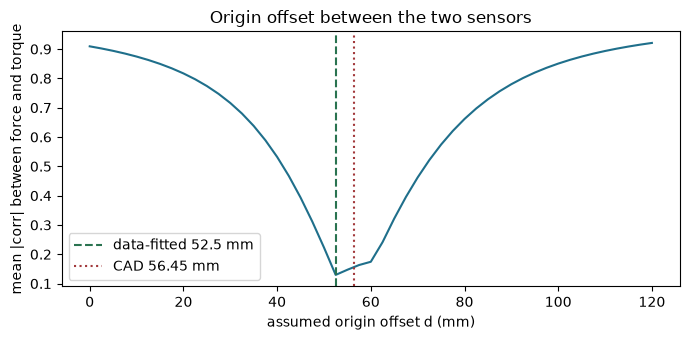

data-fitted offset : 52.5 mm
CAD  (49.2 + 7.25) : 56.45 mm
disagreement       : 3.95 mm


In [11]:
Y = np.vstack([arr(stream(s,"ufactory_calibrated"), AXES) for s in SESSIONS])

def shift_frame(y, d):
    return np.column_stack([y[:,0], y[:,1], y[:,2],
                            y[:,3] + d*y[:,1], y[:,4] - d*y[:,0], y[:,5]])

ds = np.arange(0, 0.121, 0.0025)
score = []
for d in ds:
    ys = shift_frame(Y, d)
    score.append((abs(np.corrcoef(ys[:,0],ys[:,4])[0,1]) + abs(np.corrcoef(ys[:,1],ys[:,3])[0,1]))/2)
score = np.array(score)
d_fit = ds[np.argmin(score)]

# --- your CAD numbers ---
UF_FLANGE_TO_SENSOR_MM  = 49.2    # uFactory mounting flange -> uFactory sensor origin
DIY_BACKPLATE_TO_SENS_MM = 7.25   # DIY CNC backplate -> DIY sensor origin
d_cad = (UF_FLANGE_TO_SENSOR_MM + DIY_BACKPLATE_TO_SENS_MM)/1000

fig, ax = plt.subplots(figsize=(7,3.5))
ax.plot(ds*1000, score, color="#1f6f8b")
ax.axvline(d_fit*1000, color="#2a7350", ls="--", label=f"data-fitted {d_fit*1000:.1f} mm")
ax.axvline(d_cad*1000, color="#a2383b", ls=":",  label=f"CAD {d_cad*1000:.2f} mm")
ax.set_xlabel("assumed origin offset d (mm)")
ax.set_ylabel("mean |corr| between force and torque")
ax.set_title("Origin offset between the two sensors"); ax.legend()
plt.tight_layout(); plt.show()

print(f"data-fitted offset : {d_fit*1000:.1f} mm")
print(f"CAD  (49.2 + 7.25) : {d_cad*1000:.2f} mm")
print(f"disagreement       : {abs(d_fit-d_cad)*1000:.2f} mm")

### Axis alignment check

If the two sensors' axes are aligned, pushing along one uFactory axis should move a
*consistent* set of homemade channels, and the sign should be stable across sessions.
This doesn't prove alignment on its own — it's a cross-check against the physical
measurement you're making.

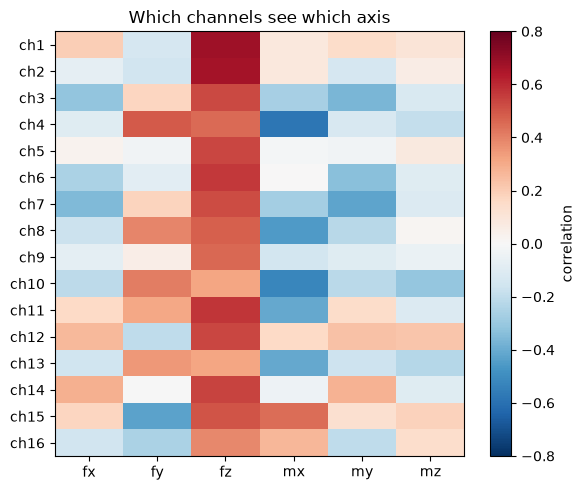

In [12]:
# Which homemade channels respond to which reference axis?
data = [load(s) for s in SESSIONS]
Xc = np.vstack([d.channels for d in data])
yc = np.vstack([d.wrench   for d in data])

corr = np.array([[np.corrcoef(Xc[:,j], yc[:,i])[0,1] for i in range(6)] for j in range(CHANNELS)])

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-.8, vmax=.8, aspect="auto")
ax.set_xticks(range(6), AXES); ax.set_yticks(range(16), [f"ch{i+1}" for i in range(16)])
ax.set_title("Which channels see which axis"); plt.colorbar(im, label="correlation")
plt.tight_layout(); plt.show()


---

## Where this leaves us

Once every step above is understood and passing, `load_corrected()` is the function that
feeds the fit. Two open decisions it exposes:

1. **Which frame should the calibration target?**
   - `frame_offset_m=0` → the homemade sensor learns to report *what the uFactory reports*.
     Good for a drop-in replacement, but the model can absorb the fixed `d·F` term rather than
     learning real torque sensitivity.
   - `frame_offset_m=d` → the homemade sensor learns the wrench about **its own origin**,
     which is the physically honest target. Harder, and it reveals how little genuine torque
     sensitivity the sensor has.

2. **Whether the loading covers enough variety** — if every push has the same force-to-torque
   ratio, no model can separate the two, whichever frame you choose.

Fit with `fit_calibration.py` once you're satisfied with the answers here.

---

# Step 11 — Experimental excitation

The question this step answers: **does the dataset contain enough independent information
to tell each output apart from the others?**

If two outputs always move together, no model can separate them — not because the sensor
can't tell, but because the experiment never showed them apart. This is a property of how
the loads were applied, not of the sensor or the maths.

Three checks:

  **11a** force ↔ torque correlations (the 3×3 grid) — where the degeneracy lives
  **11b** channel ↔ output correlations — which channel actually sees which axis
  **11c** time delay between the sensors — confirming the alignment holds per-axis

## 11a — Force ↔ torque correlation grid

Anything above ~0.9 is a warning: those two quantities are effectively one measurement
in this dataset.

In [13]:
data = [load(s) for s in SESSIONS]
Y = np.vstack([d.wrench for d in data])
F, T = Y[:, :3], Y[:, 3:]
FN, TN = ("Fx","Fy","Fz"), ("Tx","Ty","Tz")

grid = np.array([[np.corrcoef(F[:,i], T[:,j])[0,1] for j in range(3)] for i in range(3)])

print("correlation between each force and each torque (all sessions pooled)\n")
print("        " + "".join(f"{n:>9}" for n in TN))
for i, fn in enumerate(FN):
    row = "".join(f"{grid[i,j]:9.2f}" for j in range(3))
    flag = "   <-- DEGENERATE" if np.abs(grid[i]).max() > 0.9 else ""
    print(f"{fn:>6}  {row}{flag}")

print("\npairs above 0.9 (cannot be separated by ANY model):")
bad = [(FN[i], TN[j], grid[i,j]) for i in range(3) for j in range(3) if abs(grid[i,j]) > 0.9]
for a, b, v in bad:
    print(f"   {a} <-> {b}:  {v:+.2f}")
if not bad:
    print("   none")

correlation between each force and each torque (all sessions pooled)

               Tx       Ty       Tz
    Fx       0.11     0.93     0.06   <-- DEGENERATE
    Fy      -0.90    -0.07     0.01
    Fz      -0.01    -0.05    -0.04

pairs above 0.9 (cannot be separated by ANY model):
   Fx <-> Ty:  +0.93


### Why those pairs are correlated, and what to do about it

Two different causes, with two different fixes — worth separating:

1. **Frame offset (geometry, not experiment).** The two sensors sit ~56 mm apart along the
   tool axis, so `M_uf = M_diy + r × F`. That *alone* forces `Ty ≈ d·Fx` and `Tx ≈ −d·Fy`,
   no matter how carefully you load. Removable analytically — see step 10.

2. **Fixed contact point (genuine experiment limitation).** Every push went through roughly
   the same spot, so the remaining force-to-torque ratio never varied. Only fixable by
   collecting at different lever arms.

The cell below separates the two: it re-runs the grid *after* removing the frame offset.
Whatever correlation survives is the real experimental weakness.

after removing the 56.5 mm frame offset

               Tx       Ty       Tz
    Fx       0.08    -0.18     0.06
    Fy      -0.14     0.07     0.01
    Fz      -0.18    -0.16    -0.04


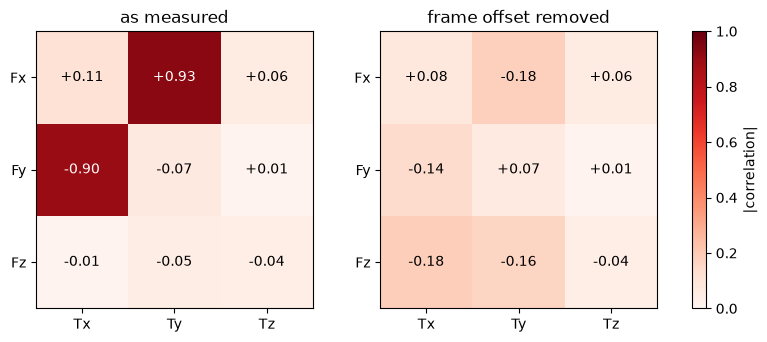


Remaining high pairs are the genuine experimental gap:
   none


In [14]:
Yc = shift_wrench_frame(Y.copy(), SENSOR_ORIGIN_OFFSET_M)
Fc, Tc = Yc[:, :3], Yc[:, 3:]
grid_c = np.array([[np.corrcoef(Fc[:,i], Tc[:,j])[0,1] for j in range(3)] for i in range(3)])

print(f"after removing the {SENSOR_ORIGIN_OFFSET_M*1000:.1f} mm frame offset\n")
print("        " + "".join(f"{n:>9}" for n in TN))
for i, fn in enumerate(FN):
    print(f"{fn:>6}  " + "".join(f"{grid_c[i,j]:9.2f}" for j in range(3)))

fig, axes = plt.subplots(1, 2, figsize=(9,3.6))
for ax, g, title in zip(axes, (grid, grid_c), ("as measured", "frame offset removed")):
    im = ax.imshow(np.abs(g), cmap="Reds", vmin=0, vmax=1)
    ax.set_xticks(range(3), TN); ax.set_yticks(range(3), FN); ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{g[i,j]:+.2f}", ha="center", va="center",
                    color="white" if abs(g[i,j])>0.55 else "black", fontsize=10)
fig.colorbar(im, ax=axes, label="|correlation|", fraction=.045)
plt.show()

print("\nRemaining high pairs are the genuine experimental gap:")
left = [(FN[i], TN[j], grid_c[i,j]) for i in range(3) for j in range(3) if abs(grid_c[i,j]) > 0.9]
print("   " + (", ".join(f"{a}<->{b} {v:+.2f}" for a,b,v in left) if left else "none"))

## 11b — Which channel sees which output?

If the sensor is working as designed, each output should be driven by a distinct,
physically sensible subset of the 16 channels. A channel that correlates with
*everything* is picking up common-mode drift rather than load; a channel that
correlates with *nothing* is contributing no information.

strongest output per channel

  ch  best axis    |r|     cluster   verdict
   1         fz   0.68           1   informative
   2         fz   0.66           1   informative
   3         fz   0.53           1   informative
   4         mx   0.58           1   informative
   5         fz   0.53           2   informative
   6         fz   0.57           2   informative
   7         fz   0.52           2   informative
   8         fz   0.48           2   informative
   9         fz   0.46           3   informative
  10         mx   0.52           3   informative
  11         fz   0.57           3   informative
  12         fz   0.53           3   informative
  13         mx   0.41           4   informative
  14         fz   0.54           4   informative
  15         fz   0.50           4   informative
  16         fz   0.39           4   weak


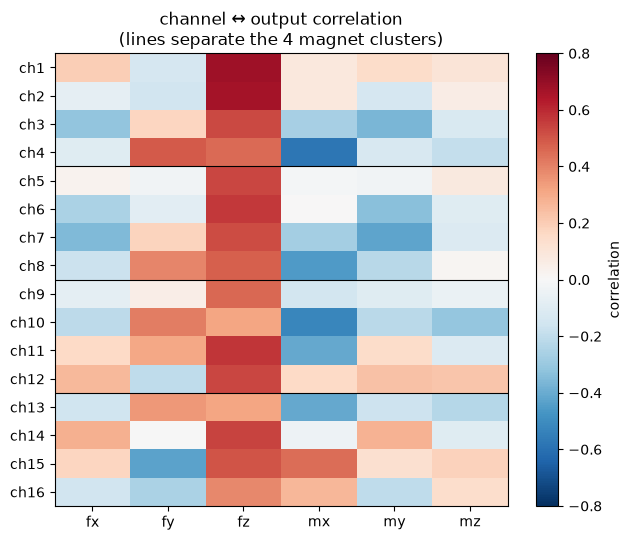

In [15]:
X = np.vstack([d.channels for d in data])
corr = np.array([[np.corrcoef(X[:,j], Y[:,i])[0,1] for i in range(6)] for j in range(CHANNELS)])

print("strongest output per channel\n")
print(f"{'ch':>4} {'best axis':>10} {'|r|':>6}   {'cluster':>9}   {'verdict'}")
for j in range(CHANNELS):
    i = int(np.argmax(np.abs(corr[j])))
    peak = abs(corr[j, i])
    spread = np.abs(corr[j]).mean()
    verdict = ("informative" if peak > 0.4 else
               "weak"        if peak > 0.2 else "contributes little")
    if peak > 0.2 and spread / peak > 0.75:
        verdict += " (broad — may be common-mode)"
    print(f"{j+1:>4} {AXES[i]:>10} {peak:6.2f}   {j//4 + 1:>9}   {verdict}")

fig, ax = plt.subplots(figsize=(6.5,5.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-.8, vmax=.8, aspect="auto")
ax.set_xticks(range(6), AXES)
ax.set_yticks(range(CHANNELS), [f"ch{i+1}" for i in range(CHANNELS)])
for c in (3.5, 7.5, 11.5):
    ax.axhline(c, color="k", lw=.8)          # magnet-cluster boundaries (4 channels each)
ax.set_title("channel ↔ output correlation\n(lines separate the 4 magnet clusters)")
plt.colorbar(im, ax=ax, label="correlation")
plt.tight_layout(); plt.show()

## 11c — Time delay between the sensors

Step 3 checked alignment using all six axes at once. Here we check **per axis**, because a
mechanical delay (flex in the mount, or the sensor's own filtering) could affect one
direction more than another.

Method: cross-correlate each homemade channel against each reference axis at a range of
lags, and report the lag with the strongest response.

session 1786497121 — lag of peak response per axis

  axis  best lag (s)   peak |r|
    fx          0.02       0.34
    fy          0.00       0.54
    fz          0.06       0.77
    mx          0.00       0.50
    my          0.04       0.43
    mz          0.08       0.23


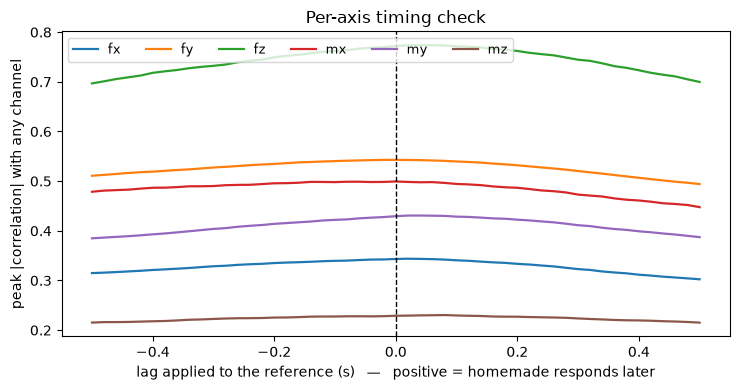


A peak at 0 means no correction is needed for that axis. A consistent non-zero
peak across axes would indicate a real transport delay worth compensating.


In [16]:
def best_lag_per_axis(session, max_lag_s=0.5, step_s=0.02):
    """Lag (seconds) at which each reference axis best matches the channels.
    Positive = the homemade sensor responds LATER than the reference."""
    uf = stream(session, "ufactory_calibrated")
    hm = stream(session, "homemade_raw")
    ut, uy = ts_of(uf), arr(uf, AXES)
    ht, Xr = ts_of(hm), arr(hm, CHAN_COLS)
    Xc = Xr - Xr.mean(axis=0)

    lags = np.arange(-max_lag_s, max_lag_s + 1e-9, step_s)
    out = np.zeros((len(lags), 6))
    for k, lag in enumerate(lags):
        y = np.column_stack([np.interp(ht + lag, ut, uy[:, i]) for i in range(6)])
        y = y - y.mean(axis=0)
        for i in range(6):
            # strongest single-channel response to this axis at this lag
            out[k, i] = max(abs(np.corrcoef(Xc[:, j], y[:, i])[0, 1]) for j in range(CHANNELS))
    return lags, out

lags, resp = best_lag_per_axis(SESSIONS[-1])
print(f"session {SESSIONS[-1]} — lag of peak response per axis\n")
print(f"{'axis':>6} {'best lag (s)':>13} {'peak |r|':>10}")
for i, a in enumerate(AXES):
    k = int(np.argmax(resp[:, i]))
    print(f"{a:>6} {lags[k]:13.2f} {resp[k, i]:10.2f}")

fig, ax = plt.subplots(figsize=(7.5,4))
for i, a in enumerate(AXES):
    ax.plot(lags, resp[:, i], label=a, lw=1.6)
ax.axvline(0, color="k", ls="--", lw=1)
ax.set_xlabel("lag applied to the reference (s)   —   positive = homemade responds later")
ax.set_ylabel("peak |correlation| with any channel")
ax.set_title("Per-axis timing check"); ax.legend(ncol=6, fontsize=9)
plt.tight_layout(); plt.show()

print("\nA peak at 0 means no correction is needed for that axis. A consistent non-zero")
print("peak across axes would indicate a real transport delay worth compensating.")

### Verdict on excitation

Read the three results together:

- **11a** tells you which outputs are inseparable, and (after the frame correction) how much
  of that is a genuine gap in the loading rather than geometry.
- **11b** tells you whether all 16 channels are earning their place.
- **11c** confirms the alignment is sound per-axis, so nothing above is a timing artifact.

Any pair still above ~0.9 in the corrected grid needs new data collected at a **different
lever arm** before fitting — no model, however sophisticated, can invent the missing
information.

---

# Step 12 — Can we recover the coordinate frames from the data?

**Partly, and the part we can recover is the useful part.**

The raw channels have *no intrinsic frame* — they're 16 ADC counts. A frame only exists
once you map them to physical axes, so if we fit channels → uFactory wrench, the fit
silently absorbs any rotation and we learn nothing about alignment.

The way around this: the firmware's **geometric model** (openFT `ft_driver.py`) maps
channels to a force vector using only the *known magnet layout* — 4 clusters at
0°/0°/240°/120°, with `dx = s1−s3`, `dy = s0−s2`, `dz = mean`. That produces a force in
the DIY sensor's **own native frame**, derived from physical geometry and independent of
anything we fit.

With a force vector in each frame, the rotation between them becomes measurable.

In [17]:
import math, itertools

CLUSTER_ANGLES = [0, 0, 240, 120]     # openFT ft_driver.py

def geometric_force(channels):
    """(N,16) channels -> (N,3) force in the DIY sensor's NATIVE frame (arbitrary units).

    Straight from the firmware's geometric model: per cluster, a differential pair gives
    lateral displacement and the cluster mean gives axial, then each cluster is rotated
    into the sensor frame by its mounting angle.
    """
    fx = fy = fz = np.zeros(len(channels))
    fx, fy, fz = (np.zeros(len(channels)) for _ in range(3))
    for i in range(4):
        c  = channels[:, i*4:(i+1)*4]
        lx = c[:, 1] - c[:, 3]      # differential -> cancels common-mode drift
        ly = c[:, 0] - c[:, 2]
        lz = c.mean(axis=1)         # common mode  -> shares drift with thermal effects
        a  = math.radians(CLUSTER_ANGLES[i])
        fx += lx*math.cos(a) - ly*math.sin(a)
        fy += lx*math.sin(a) + ly*math.cos(a)
        fz += lz
    return np.column_stack([fx, fy, fz])

data = [load(s, filter_window=35) for s in SESSIONS]
G = geometric_force(np.vstack([d.channels for d in data]))   # DIY native frame
F = np.vstack([d.wrench for d in data])[:, :3]               # uFactory frame

Gn, Fn = G/G.std(axis=0), F/F.std(axis=0)                    # units differ; compare shapes
print(f"{len(G):,} samples")
print("geometric force std (native units):", G.std(axis=0).round(2))
print("uFactory   force std (N)          :", F.std(axis=0).round(2))

79,636 samples
geometric force std (native units): [17.04 18.47 11.92]
uFactory   force std (N)          : [18.15 16.64 18.63]


## 12a — Which axis-aligned rotation fits best?

Physical mountings are almost always axis-aligned, so rather than fitting a free rotation
(which noise will happily bend), we test all **24 proper axis-aligned rotations** and rank them.

A candidate is only credited if it explains the data with a **positive gain** — a negative
gain means that axis' sign is wrong, so it scores zero rather than being rewarded for
matching in magnitude.

In [18]:
def axis_aligned_rotations():
    """The 24 signed permutation matrices with det = +1 (proper rotations, no reflection)."""
    out = []
    for perm in itertools.permutations(range(3)):
        for signs in itertools.product([1, -1], repeat=3):
            R = np.zeros((3, 3))
            for row, (col, s) in enumerate(zip(perm, signs)):
                R[row, col] = s
            if np.linalg.det(R) > 0:
                out.append(R)
    return out

def score(R):
    """Mean R2 after rotating G into the uFactory frame, one free positive gain per axis."""
    P, per = Gn @ R.T, []
    for i in range(3):
        gain = np.dot(P[:, i], Fn[:, i]) / max(np.dot(P[:, i], P[:, i]), 1e-12)
        per.append(1 - (Fn[:, i] - gain*P[:, i]).var()/Fn[:, i].var() if gain > 0 else 0.0)
    return float(np.mean(per)), np.array(per)

def axis_name(R, j):
    col = R[:, j]; k = int(np.argmax(np.abs(col)))
    return ("+" if col[k] > 0 else "-") + "XYZ"[k]

ranked = sorted(((score(R)[0], R) for R in axis_aligned_rotations()), key=lambda t: -t[0])

print(f"{'rank':>4} {'DIY +X ->':>10} {'DIY +Y ->':>10} {'DIY +Z ->':>10} {'mean R2':>9}   per-axis")
for rank, (s, R) in enumerate(ranked[:6], 1):
    _, per = score(R)
    print(f"{rank:>4} {axis_name(R,0):>10} {axis_name(R,1):>10} {axis_name(R,2):>10} {s:9.3f}   "
          + " ".join(f"{v:.2f}" for v in per))

best_score, best_R = ranked[0]
identity_score = next(s for s, R in ranked if np.allclose(R, np.eye(3)))
print(f"\nbest {best_score:.3f} | runner-up {ranked[1][0]:.3f} | identity {identity_score:.3f}")
print(f"margin over runner-up: {best_score - ranked[1][0]:+.3f}"
      "   (a large margin means the winner is not a coin-flip)")

rank  DIY +X ->  DIY +Y ->  DIY +Z ->   mean R2   per-axis
   1         -Y         +X         +Z     0.395   0.22 0.44 0.53
   2         -X         -Y         +Z     0.199   0.00 0.07 0.53
   3         +X         +Y         +Z     0.176   0.00 0.00 0.53
   4         +Y         -X         +Z     0.175   0.00 0.00 0.53
   5         -Y         +Z         -X     0.155   0.00 0.44 0.03
   6         -Y         -X         -Z     0.145   0.00 0.44 0.00

best 0.395 | runner-up 0.199 | identity 0.176
margin over runner-up: +0.195   (a large margin means the winner is not a coin-flip)


## 12b — Sanity check with a free rotation

If the discrete winner is right, an unconstrained rotation fit should land near it.
This also reports the **determinant**: `+1` is a proper rotation, `−1` would mean the two
frames have opposite handedness — worth knowing, and not something you'd spot by eye.

In [19]:
U, S, Vt = np.linalg.svd(Gn.T @ Fn)
R_free = (U @ Vt).T
det = np.linalg.det(R_free)
angle = math.degrees(math.acos(np.clip((np.trace(R_free)-1)/2, -1, 1)))

np.set_printoptions(precision=3, suppress=True)
print("free-rotation fit (DIY native -> uFactory):")
print(R_free)
print(f"\ndeterminant  {det:+.3f}   ({'proper rotation' if det > 0 else 'REFLECTION — handedness differs!'})")
print(f"rotation angle {angle:.1f} deg")
print(f"singular values {S.round(0)}  (all comparable = every axis is determined)")

print("\nnearest axis-aligned candidate:")
print(best_R)
print(f"agreement with the free fit: {np.abs(R_free - best_R).max():.2f} max element difference")

free-rotation fit (DIY native -> uFactory):
[[-0.221  0.961 -0.166]
 [-0.974 -0.21   0.084]
 [ 0.046  0.18   0.983]]

determinant  +1.000   (proper rotation)
rotation angle 103.0 deg
singular values [63573. 58405. 31409.]  (all comparable = every axis is determined)

nearest axis-aligned candidate:
[[ 0.  1.  0.]
 [-1.  0.  0.]
 [ 0.  0.  1.]]
agreement with the free fit: 0.22 max element difference


### What this tells us — and what it doesn't

**Determinable from data:** the axis mapping and handedness between the two frames.

**Not determinable:** the DIY sensor's *absolute* orientation in the world. We only ever see
it relative to the uFactory, so this answers "how are the two related", not "which way does
the DIY sensor point".

**Important caveat:** this inherits any error in the firmware's geometric model. If
`CLUSTER_ANGLES` or the differential pairings in `ft_driver.py` don't match how your board
was actually assembled, the rotation reported here is wrong by exactly that amount. Treat
it as a strong cross-check against your physical measurement, not a replacement for it.

The absolute R² values are low (the geometric model is a weak predictor on this hardware),
but the *relative ranking* is what identifies the rotation — and that margin is what to
judge, not the absolute fit.